# 成都二手房单价预测 · 完整流程代码（全解参考版）

> 对应 `综合题-成都房价.ipynb` 的 8 处 TODO 全部完成后的完整流水线。
> 用途：提交版 + 对照参考。数据文件需放在 `practice/data/chengdu_house.csv`。

## 整体框架（一条流水线）

```
数据加载 → 特征工程 → 数据清洗 → 划分/标准化 → 张量+DataLoader → 模型+训练 → 评估+新样本预测
  (csv)    (正则+one-hot) (填缺失+滤异常) (80/20+z-score)  (torch)      (Linear+Adam)    (RMSE/MAE)
```

| 步骤 | 输入 | 输出 | 关键动作 |
|---|---|---|---|
| ① 加载 | csv 文件 | DataFrame (14838, 16) | read_csv |
| ② 特征工程 | 原始 df | 特征表 (n, 128) | 正则拆户型/楼层 + one-hot |
| ③ 清洗 | 特征表 | 干净特征 + 标签 | 填中位数 + 删异常行 |
| ④ 划分/标准化 | 干净数据 | 训练/测试集 | 80/20 随机划分 + z-score |
| ⑤ 张量 | DataFrame | torch 张量 | .values + float32 + DataLoader |
| ⑥ 训练 | 张量 | 模型 | Linear + MSELoss + Adam，50 epochs |
| ⑦ 评估 | 模型 | RMSE/MAE | 反变换回真实价格 + 新样本预测 |


In [1]:
# ===== 第 0 步 · 导入与数据加载 =====
%matplotlib inline
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils import data
import re
import os

# 列名映射（如果数据集的列名不同，改这里）
COL = {
    '户型': '房屋户型',
    '楼层': '所在楼层',
    '面积': '建筑面积（平方米）',
    '市辖区': '房屋所属市辖区',
    '朝向': '房屋朝向',
    '装修': '装修情况',
    '结构': '建筑结构',
    '电梯': '配备电梯',
    '单价': '单价（元/平方米）',
}

CSV_PATH = '../data/chengdu_house.csv'
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError('请把 chengdu_house.csv 放到 practice/data/ 下')
df = pd.read_csv(CSV_PATH)
print('已加载，样本数:', len(df), ' 列数:', df.shape[1])

已加载，样本数: 14838  列数: 16


## 第 1 步 · 特征工程（正则拆文本 + one-hot）

In [2]:
# ===== TODO 1 · 户型解析：'2室1厅1厨1卫' -> (室, 厅, 厨, 卫)，缺失填 0 =====
def parse_hu_xing(s):
    def pick(pattern):
        m = re.search(pattern, str(s))       # 匹配
        return int(m.group(1)) if m else 0   # 匹配到取括号捕获的数字，否则填 0
    return pick(r'(\d+)室'), pick(r'(\d+)厅'), pick(r'(\d+)厨'), pick(r'(\d+)卫')


# ===== TODO 2 · 楼层解析：'高楼层 (共7层)' -> (位置编码, 总楼层) =====
# 位置编码: 低=0、中=1、高=2；总楼层取不到返回 None
def parse_floor(s):
    s = str(s)
    if '低' in s:
        pos = 0
    elif '中' in s:
        pos = 1
    else:
        pos = 2      # 默认按「高」处理（真实数据里多数是高中低三种，其他归高）
    m = re.search(r'共(\d+)层', s)
    total = int(m.group(1)) if m else None
    return pos, total

In [3]:
# ===== TODO 3 · 特征构建：数值列 + 类别 one-hot =====
def build_features(df):
    feat = pd.DataFrame()
    # 数值特征：户型拆出的室/厅/厨/卫
    hu = df[COL['户型']].apply(parse_hu_xing)
    feat['室'] = [h[0] for h in hu]
    feat['厅'] = [h[1] for h in hu]
    feat['厨'] = [h[2] for h in hu]
    feat['卫'] = [h[3] for h in hu]
    # 数值特征：楼层位置 + 总楼层
    fl = df[COL['楼层']].apply(parse_floor)
    feat['楼层位置'] = [f[0] for f in fl]
    feat['总楼层'] = [f[1] for f in fl]
    # 数值特征：建筑面积
    feat['建筑面积'] = df[COL['面积']]
    # 类别特征：one-hot（先 fillna('未知') 再编码，避免整行全 0）
    cat_cols = [COL['市辖区'], COL['朝向'], COL['装修'], COL['结构'], COL['电梯']]
    for col in cat_cols:
        filled = df[col].fillna('未知')
        dummies = pd.get_dummies(filled, prefix=col)
        feat = pd.concat([feat, dummies], axis=1)
    return feat

feat_df = build_features(df)
print('特征表形状:', feat_df.shape)

特征表形状: (14838, 128)


## 第 2 步 · 数据清洗（填缺失 + 滤异常）

In [4]:
# ===== TODO 4 · 清洗：数值缺失填中位数，异常行整行删除 =====
def clean_data(feat_df, label_series):
    feat = feat_df.copy()
    y = label_series.copy()
    # 真实数据里数值列可能混有「暂无」这类字符串：先转数值，转不了的变 NaN
    feat['总楼层'] = pd.to_numeric(feat['总楼层'], errors='coerce')
    feat['建筑面积'] = pd.to_numeric(feat['建筑面积'], errors='coerce')
    # 缺失值填中位数（比均值抗异常值）
    feat['总楼层'] = feat['总楼层'].fillna(feat['总楼层'].median())
    feat['建筑面积'] = feat['建筑面积'].fillna(feat['建筑面积'].median())
    # 异常行过滤：面积 <=0 或 >500、单价 <=0 删除
    mask = (feat['建筑面积'] > 0) & (feat['建筑面积'] <= 500) & (y > 0)
    return feat[mask].reset_index(drop=True), y[mask].reset_index(drop=True)

X_raw, y_raw = clean_data(feat_df, df[COL['单价']])
print('清洗后样本数:', len(X_raw), ' 特征形状:', X_raw.shape)

清洗后样本数: 14834  特征形状: (14834, 128)


## 第 3 步 · 划分与标准化（80/20 + z-score）

In [5]:
# ===== TODO 5 · 随机划分 80/20，用「训练集」的统计量做 z-score =====
NUM_COLS = ['室', '厅', '厨', '卫', '楼层位置', '总楼层', '建筑面积']

num_examples = len(X_raw)
idx = torch.randperm(num_examples).tolist()       # 随机打乱索引
n_train = int(0.8 * num_examples)
train_idx, test_idx = idx[:n_train], idx[n_train:]

# 只用训练集的统计量（测试集模拟「未来数据」，不能偷看它的统计量）
train_mean = X_raw.iloc[train_idx][NUM_COLS].mean()
train_std = X_raw.iloc[train_idx][NUM_COLS].std()
y_mean = float(y_raw.iloc[train_idx].mean())
y_std = float(y_raw.iloc[train_idx].std())

def norm(part):
    out = part.copy()
    out[NUM_COLS] = (out[NUM_COLS] - train_mean) / train_std   # z-score
    return out

X_train = norm(X_raw.iloc[train_idx]).reset_index(drop=True)
X_test = norm(X_raw.iloc[test_idx]).reset_index(drop=True)
y_train = (y_raw.iloc[train_idx].values - y_mean) / y_std     # 标签也标准化
y_test = (y_raw.iloc[test_idx].values - y_mean) / y_std
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (11867, 128)  X_test: (2967, 128)


## 第 4 步 · 转张量 + DataLoader

In [6]:
# ===== TODO 6 · DataFrame -> 张量 -> TensorDataset -> DataLoader =====
train_ds = data.TensorDataset(
    torch.tensor(X_train.astype('float32').values),          # 特征 -> (n,128) 张量
    torch.tensor(y_train.astype('float32')).reshape(-1, 1))  # 标签 -> (n,1) 列向量
train_iter = data.DataLoader(train_ds, batch_size=64, shuffle=True)

X_test_t = torch.tensor(X_test.astype('float32').values)    # 测试集直接转张量（不需分批）
y_test_t = torch.tensor(y_test.astype('float32')).reshape(-1, 1)
print('训练批次数:', len(train_iter))

训练批次数: 186


## 第 5 步 · 模型与训练

In [7]:
# ===== TODO 7 · Linear + MSELoss + Adam，50 epochs =====
num_features = X_train.shape[1]
net = nn.Sequential(nn.Linear(num_features, 1))       # 128 特征 -> 1 个预测值
loss = nn.MSELoss()
trainer = torch.optim.Adam(net.parameters(), lr=0.05)

num_epochs = 50
history = []
for epoch in range(num_epochs):
    epoch_l = 0.0
    for Xb, yb in train_iter:
        l = loss(net(Xb), yb)        # ① 前向 + 损失
        trainer.zero_grad()           # ② 清梯度
        l.backward()                  # ③ 反向
        trainer.step()                # ④ 更新
        epoch_l += float(l) * len(Xb) # 加权累加（最后一批可能不满）
    history.append(epoch_l / len(X_train))
    if (epoch + 1) % 10 == 0:
        print(f'epoch {epoch + 1}, loss {history[-1]:.4f}')

epoch 10, loss 0.3063
epoch 20, loss 0.3007
epoch 30, loss 0.3008
epoch 40, loss 0.3050
epoch 50, loss 0.3023


## 第 6 步 · 评估 + 新样本预测

In [8]:
# ===== TODO 8a · 测试集 RMSE / MAE（反变换回真实价格） =====
net.eval()
with torch.no_grad():
    pred_test = net(X_test_t).reshape(-1)
    pred_real = pred_test * y_std + y_mean        # 预测反变换回元/平方米
    y_real = y_test_t.reshape(-1) * y_std + y_mean
    rmse = float(((pred_real - y_real) ** 2).mean() ** 0.5)
    mae = float((pred_real - y_real).abs().mean())
print(f'测试集 RMSE: {rmse:.0f} 元/平方米  MAE: {mae:.0f} 元/平方米')


# ===== TODO 8b · 新样本走一遍完整特征工程后预测 =====
new_sample = pd.DataFrame([{
    COL['市辖区']: '青羊', COL['户型']: '2室1厅1厨1卫',
    COL['楼层']: '高楼层 (共7层)', COL['面积']: 87.22,
    COL['朝向']: '北', COL['装修']: '精装', COL['结构']: '砖混结构',
    COL['电梯']: '无',
}])
new_feat = build_features(new_sample)                       # ① 同样的特征工程
new_feat = new_feat.reindex(columns=X_train.columns, fill_value=0)  # ② 列对齐（缺的补 0）
new_feat[NUM_COLS] = (new_feat[NUM_COLS] - train_mean) / train_std  # ③ 同样的标准化
new_x = torch.tensor(new_feat.astype('float32').values)
with torch.no_grad():
    new_pred = net(new_x).item() * y_std + y_mean          # ④ 预测 + 反变换
print(f'新样本（青羊 87.22㎡ 精装）预测单价: {new_pred:.0f} 元/平方米')

测试集 RMSE: 5670 元/平方米  MAE: 4079 元/平方米
新样本（青羊 87.22㎡ 精装）预测单价: 13894 元/平方米


## 损失曲线（可选）

```python
import matplotlib.pyplot as plt
plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('loss（标准化尺度）'); plt.title('训练损失曲线')
plt.show()
```

D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\anaconda3\envs\d2l\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 23610 (\N{CJK UNIFIED IDEOGRAPH-5C3A}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
D:\an

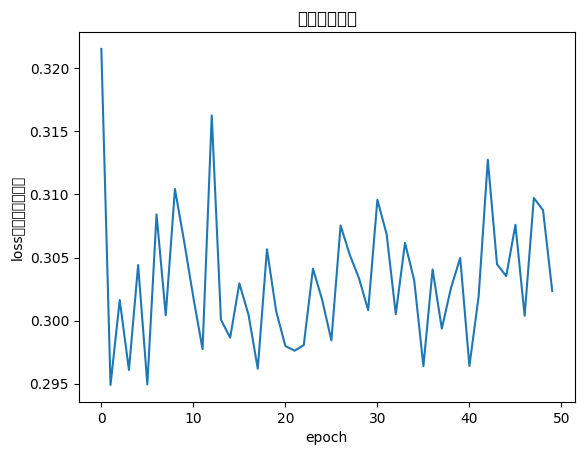

In [10]:
import matplotlib.pyplot as plt
plt.plot(history)
plt.xlabel('epoch'); plt.ylabel('loss（标准化尺度）'); plt.title('训练损失曲线')
plt.show()